# Visualization of the network

Plot a network of at least 50 nodes, showing at least 5 properties (for example 2 node properties and 3 edge properties) using the parameters that we have learnt. You should do it both with NetwsorkX and with Cytoscape.

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
import numpy as np
import pandas as pd
from itertools import combinations


Number of communities: 39


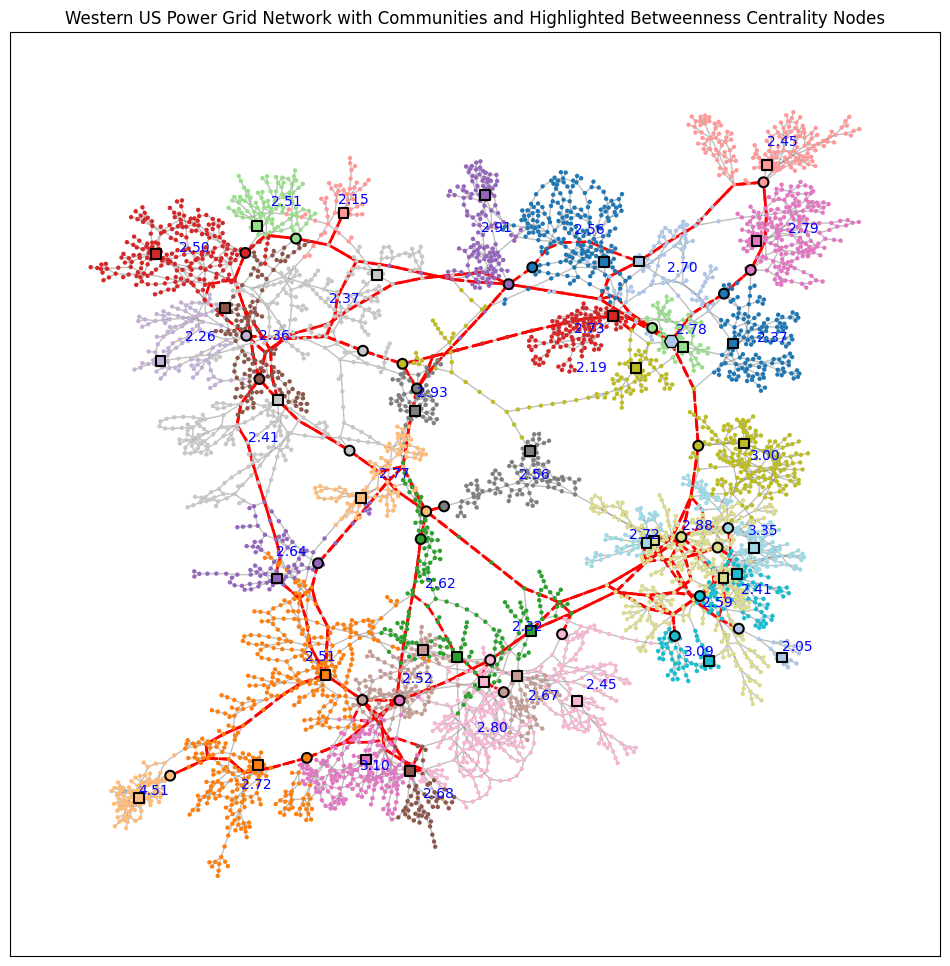

In [ ]:
"""
Here we do a visualization of the west power grid of the United States. 

-Each community is displayed with a different color
-Highest betweenness centrality node of each community
-Highest degree node in each community
-Shortest paths between highest betweenness centrality nodes in each community
-Community centrality
-Highlighting with a hexagon the node with the highest betweennes centrality of the network
"""

G = nx.read_edgelist(r"C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_networks_report\my_project\power_grid_network\edges.csv", delimiter=",", nodetype = int)
# Load data
nodes_path = r'C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_networks_report\my_project\power_grid_network\nodes.csv'
edges_path = r'C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_networks_report\my_project\power_grid_network\edges.csv'

nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)

# Define a function to parse the position strings
def parse_position(pos_str):
    """Convert position string to a tuple of floats."""
    return tuple(map(float, pos_str.strip('array()[]').split(',')))

# Apply the function to the 'pos' column
nodes_df['pos'] = nodes_df['pos'].apply(parse_position)

# Create a dictionary of positions
positions = {row['#index']: row['pos'] for _, row in nodes_df.iterrows()}



# Perform community detection
partition = community_louvain.best_partition(G)

# Print the number of communities
N_comm = len(set(partition.values()))
print(f"Number of communities: {N_comm}")
# Calculate betweenness centrality for all nodes in the graph
betweenness = nx.betweenness_centrality(G)

# Find the node with highest betweenness centrality in each community
highlighted_nodes = []
for community in set(partition.values()):
    # Get all nodes in this community
    community_nodes = [n for n in G.nodes if partition[n] == community]
    # Find the node with highest betweenness centrality in the community
    highest_betweenness_node = max(community_nodes, key=lambda node: betweenness[node])
    highlighted_nodes.append(highest_betweenness_node)


highest_degree_nodes = []
for community in set(partition.values()):
    # Get all nodes in this community
    community_nodes = [n for n in G.nodes if partition[n] == community]
    # Find the node with the highest degree in the community
    highest_degree_node = max(community_nodes, key=lambda node: degree[node])
    highest_degree_nodes.append(highest_degree_node)



# Community centrality
degree = dict(G.degree())
avg_degree_centrality = {}
for community in set(partition.values()):
    community_nodes = [node for node in G.nodes if partition[node] == community]
    avg_degree_centrality[community] = sum(degree[node] for node in community_nodes) / len(community_nodes)

# shortest path between hihglighted nodes
shortest_paths_edges = set()
for source, target in combinations(highlighted_nodes, 2):
    shortest_path = nx.shortest_path(G, source=source, target=target, weight=None)
    shortest_paths_edges.update(zip(shortest_path[:-1], shortest_path[1:]))

# Identify the node with the highest betweenness centrality in the entire network
highest_betweenness_node = max(betweenness, key=betweenness.get)


# Create a color map to assign one color per community
cmap = plt.cm.tab20
colors = [cmap(partition[node] / max(partition.values())) for node in G.nodes()]
plt.figure(figsize=(12, 12))
# Draw edges first
nx.draw_networkx_edges(G, pos=positions, alpha=0.5, edge_color="gray")

# Draw non-highlighted nodes
non_highlighted_nodes = [node for node in G.nodes() if node not in highlighted_nodes]
nx.draw_networkx_nodes(
    G, pos=positions,
    nodelist=non_highlighted_nodes,  # Only non-highlighted nodes
    node_color=[colors[i] for i, node in enumerate(G.nodes()) if node not in highlighted_nodes],
    node_size=10,
    edgecolors='none'  # No border for non-highlighted nodes
)


# Identify the community containing this node
highlighted_community = partition[highest_betweenness_node]

# Draw highlighted nodes on top
nx.draw_networkx_nodes(
    G, pos=positions,
    nodelist=highlighted_nodes,  # Only highlighted nodes
    node_color=[colors[list(G.nodes()).index(node)] for node in highlighted_nodes],  # Use the same color as the community
    node_size=50,  # Larger size for highlighted nodes
    edgecolors='black',  # Black border for highlighted nodes
    linewidths=1.5  # Thicker border
)
# Highlight shortest paths
nx.draw_networkx_edges(
    G, pos=positions,
    edgelist=shortest_paths_edges,
    edge_color="red",
    style="dashed",
    width=2
)

# Draw highest-degree nodes (with square shape)
nx.draw_networkx_nodes(
    G, pos=positions,
    nodelist=highest_degree_nodes,  # Only highest-degree nodes
    node_color=[colors[list(G.nodes()).index(node)] for node in highest_degree_nodes],  # Same color as community
    node_size=50,  # Even larger size
    edgecolors='black',  # Black border
    linewidths=1.5,  # Thicker border
    node_shape='s'  # Square shape
)

# Highlight the node with the highest betweenness centrality with a star
nx.draw_networkx_nodes(
    G, pos=positions,
    nodelist=[highest_betweenness_node],  # Only the highest betweenness centrality node
    node_color=[colors[list(G.nodes()).index(highest_betweenness_node)]],  # Use the same color as the community
    node_size=100,  # Larger size for the star node
    edgecolors='black',  # Black border
    node_shape='H'  # Triangle shape
)

# Add community centrality annotations
for community, centrality in avg_degree_centrality.items():
    community_nodes = [node for node in G.nodes if partition[node] == community]
    community_pos = np.mean([positions[node] for node in community_nodes], axis=0)
    plt.text(community_pos[0], community_pos[1], f'{centrality:.2f}', fontsize=10, color='blue')


# Add a title and show the plot
plt.title('Western US Power Grid Network with Communities and Highlighted Betweenness Centrality Nodes')
plt.show()
